# Fake News Classification with Naive Bayes

## Summary

In this Project I use the Fake and Real Dataset for training a classifier. First we wrangle the Data and take a quick look at it. Then we prepare the textdata for training. Lastly we train a Naive Bayes Classifier with the data.

- [Wrangle Data](#wrangle-data)
- [Preparing the textdata](#preparing-the-textdata)
- [Training a model](#training-a-model)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-and-real-news-dataset/True.csv
/kaggle/input/fake-and-real-news-dataset/Fake.csv


## Wrangle Data

In [2]:
df_fake = pd.read_csv('/kaggle/input/fake-and-real-news-dataset/Fake.csv')
df_true = pd.read_csv('/kaggle/input/fake-and-real-news-dataset/True.csv')

In [3]:
df_fake['label']=0
df_true['label']=1

In [4]:
df_fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [5]:
news = pd.concat([df_fake,df_true],axis=0)
news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [6]:
news.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [7]:
print("Total Articles:", news.shape[0])
news.drop_duplicates(inplace=True)
print("After dropping duplicates :",news.shape[0])

Total Articles: 44898
After dropping duplicates : 44689


In [8]:
import matplotlib.pyplot as plt

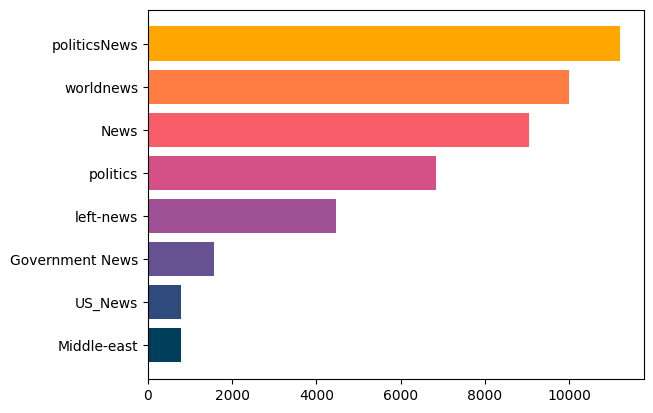

In [9]:
count=news["subject"].value_counts()
colors=['#003f5c',
'#2f4b7c',
'#665191',
'#a05195',
'#d45087',
'#f95d6a',
'#ff7c43',
'#ffa600']
plt.barh(count.index[::-1],count.values[::-1],color=colors)
plt.show()

## Preparing the Textdata

In [10]:
import re
from nltk.corpus import stopwords 
from nltk.stem import PorterStemmer

text = "Hellllllooooo"
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocessing(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    #text = re.sub(r'(.)\1{1,}', r'\1', text)
    text = text.split(" ")
    text = [stemmer.stem(word) for word in text if word not in  stop_words]
    text = " ".join(text)
    return text

In [11]:
#print(news.loc[0]["text"].values)
news["clean_text"] = news["text"].apply(preprocessing)
print(news.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label                                         clean_text  
0  December 31, 2017      0  donald trump wish american happi new year leav...  
1  December 31, 2017      0  hous intellig committe chairman devin nune go ...  
2  December 30, 2017      0  friday

<FreqDist with 85729 samples and 10439165 outcomes>


<Axes: xlabel='Samples', ylabel='Cumulative Counts'>

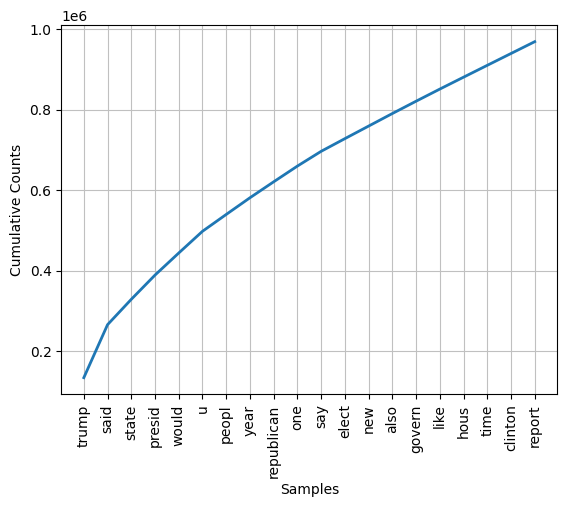

In [12]:
from nltk import FreqDist
from nltk.tokenize import word_tokenize
text = news["clean_text"][:]
text_tokenized = word_tokenize(str(" ".join(text)))
fre_distribution = FreqDist(text_tokenized)
print(fre_distribution )
fre_distribution.plot(20, cumulative=True)

In [13]:
fre_distribution.most_common(20)

[('trump', 134274),
 ('said', 131629),
 ('state', 62945),
 ('presid', 60188),
 ('would', 54814),
 ('u', 53917),
 ('peopl', 41836),
 ('year', 41430),
 ('republican', 39634),
 ('one', 39042),
 ('say', 36650),
 ('elect', 31487),
 ('new', 31176),
 ('also', 31174),
 ('govern', 30581),
 ('like', 30116),
 ('hous', 29558),
 ('time', 29448),
 ('clinton', 29372),
 ('report', 29362)]

## Training a Model

In [14]:
from sklearn.model_selection import train_test_split

X = news["clean_text"]
y = news['label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidconverter = TfidfVectorizer()

X_vectorized_train = tfidconverter.fit_transform(X_train)
x_vectorized_test = tfidconverter.transform(X_test)

In [16]:
from sklearn.naive_bayes import MultinomialNB 

model = MultinomialNB()
model.fit(X_vectorized_train,y_train)
y_pred = model.predict(x_vectorized_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9262698590288655